In [102]:
%load_ext autoreload
%autoreload 2

import torch
import math
import matplotlib.pyplot as plt
from pprint import pprint

from gllvm.glm_fit import initial_gaussian_fit, poisson_newton_batch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device=', device)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
device= cuda


In [ ]:
# -- Simulate a small example --
torch.manual_seed(123)
p, q, n = 400000, 2, 20
alpha = .5
X = alpha * torch.randn(p, q, device=device)
B_true = 0.6 * torch.randn(q, n, device=device)
eta = X @ B_true
offset = .2 * torch.randn(p, n, device=device)
Y = torch.poisson(torch.exp(eta + offset))
print('shapes: X', X.shape, 'Y', Y.shape, 'B_true', B_true.shape)

shapes: X torch.Size([400000, 2]) Y torch.Size([400000, 20]) B_true torch.Size([2, 20])


In [104]:
eta.max()

tensor(3.2962, device='cuda:0')

In [105]:
Y.max()

tensor(77., device='cuda:0')

In [106]:
from time import time

In [107]:
# -- Gaussian init (log1p least squares) --
t1 = time()
for i in range(20):
    B0 = initial_gaussian_fit(X, Y)  # (q, n)
t2 = time()

print(f"Average time per run : {(t2-t1)/20:.3f}s'")
print('B0 shape', B0.shape)
init_rel_err = torch.norm(B0 - B_true) / (torch.norm(B_true) + 1e-12)
print(f'init rel err: {init_rel_err:.4f}')

Average time per run : 0.006s'
B0 shape torch.Size([2, 20])
init rel err: 0.5146
init rel err: 0.5146


In [108]:
# -- Run batched Newton refinement --
t1 = time()
for i in range(2):
    B_hat, info = poisson_newton_batch(X, Y, B0, lam=0, max_iter=50, tol=1e-7, verbose=True, offset=-offset)
t2 = time()
print(f'Average time per run: {(t2 - t1) / 2:.3f}s')
print('Newton info:')
pprint(info)
rel_err = torch.norm(B_hat - B_true) / (torch.norm(B_true) + 1e-12)
print(f'final rel err: {rel_err:.4f}')

Newton it=  1 rel_change=1.223e+00 halvings=0
Newton it=  2 rel_change=7.524e-02 halvings=0
Newton it=  3 rel_change=5.010e-03 halvings=0
Newton it=  4 rel_change=2.510e-05 halvings=0
Newton it=  5 rel_change=2.264e-08 halvings=0
Newton it=  1 rel_change=1.223e+00 halvings=0
Newton it=  2 rel_change=7.524e-02 halvings=0
Newton it=  3 rel_change=5.010e-03 halvings=0
Newton it=  4 rel_change=2.510e-05 halvings=0
Newton it=  5 rel_change=2.264e-08 halvings=0
Average time per run: 0.050s
Newton info:
{'iters': 5, 'rel_change': 2.2640637808990505e-08}
final rel err: 0.0065


In [109]:
# -- Test with an offset term (p x n) --
offset_true = 0.2 * torch.randn(X.shape[0], Y.shape[1], device=device)
eta2 = X @ B_true + offset_true
Y2 = torch.poisson(torch.exp(eta2))
B0_off = initial_gaussian_fit(X, Y2, offset=offset_true)
B_hat2, info2 = poisson_newton_batch(X, Y2, B0_off, offset=offset_true, lam=1e-3, max_iter=50)
rel_err2 = torch.norm(B_hat2 - B_true) / (torch.norm(B_true) + 1e-12)
print(f'offset test rel err: {rel_err2:.4f}')

offset test rel err: 0.0048


## Visual check: pick one column and compare

/tmp/ipykernel_1184/1594906634.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


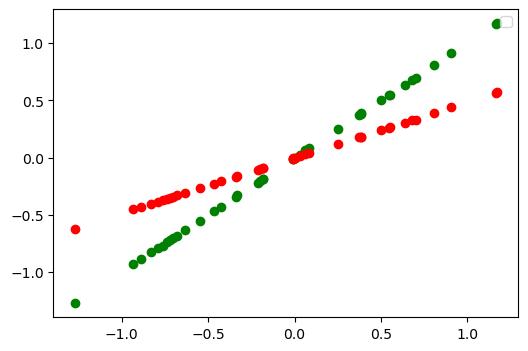

In [110]:
col = 0
plt.figure(figsize=(6,4))
plt.scatter(B_true.detach().flatten().cpu().numpy(), B_hat.detach().flatten().cpu().numpy(), c="green")
plt.scatter(B_true.detach().flatten().cpu().numpy(), B0.detach().flatten().cpu().numpy(), c="red")
plt.legend()
plt.show()

In [111]:
print(torch.norm(B_hat-B_true))

tensor(0.0258, device='cuda:0')
